# 07 — Final evaluation: rolling-origin validation + honest limitations

**Purpose of this notebook, stated plainly:** a single train/test split (notebook 06's result) is
one data point. If that particular cutoff happened to be unusually easy or hard, the reported
numbers would be misleading. Rolling-origin validation repeats the split across multiple windows
and reports the average — the same technique from the coach's own forecasting curriculum
(notebook 5, "Rolling-origin cross-validation"), applied here to a classification target instead
of a continuous one.

This is also the **final consolidated write-up** for the rebuild — every honest caveat surfaced
across notebooks 01-06 is restated here in one place, so nothing gets lost or forgotten between
this notebook and the coach conversation.


In [1]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, recall_score, precision_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## 1. Load

In [2]:
df = pd.read_csv("../data/processed/heavy_user_features.csv", parse_dates=["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)
df["Fault_Within_6h"] = df["Fault_Within_6h"].astype(bool)

with open("../data/processed/selected_feature_cols.json") as f:
    SELECTED_FEATURE_COLS = json.load(f)

print(f"{len(df):,} rows, {len(SELECTED_FEATURE_COLS)} selected features.")


43,771 rows, 45 selected features.


## 2. Rolling-origin validation setup

Four windows, each the same size as the original test set (~8,755 rows, ~20% of the data), sliding
forward through the timeline. Window 4 is the same split notebook 06 already evaluated on — included
here so it's directly comparable, not a separate number reported in isolation.


In [3]:
WINDOW_SIZE = 8755
N_SPLITS = 4

total_len = len(df)
first_test_start = total_len - N_SPLITS * WINDOW_SIZE
splits = []
for i in range(N_SPLITS):
    test_start = first_test_start + i * WINDOW_SIZE
    test_end = test_start + WINDOW_SIZE
    splits.append((0, test_start, test_start, test_end))

for i, (tr_start, tr_end, te_start, te_end) in enumerate(splits):
    print(f"Window {i+1}: train rows [0:{tr_end}] ({tr_end:,} rows), "
          f"test rows [{te_start}:{te_end}] ({te_end - te_start:,} rows)")


Window 1: train rows [0:8751] (8,751 rows), test rows [8751:17506] (8,755 rows)
Window 2: train rows [0:17506] (17,506 rows), test rows [17506:26261] (8,755 rows)
Window 3: train rows [0:26261] (26,261 rows), test rows [26261:35016] (8,755 rows)
Window 4: train rows [0:35016] (35,016 rows), test rows [35016:43771] (8,755 rows)


## 3. Fit both models on each window, using notebook 06's already-tuned hyperparameters

Re-running a full search on every window would be expensive and isn't the point here — the point is
checking whether *the chosen configuration's* performance is stable across time, not re-tuning per
window (which would itself be a form of leakage-adjacent overfitting to each window).


In [4]:
RF_BEST_PARAMS = dict(n_estimators=80, max_depth=10, min_samples_leaf=5,
                      class_weight="balanced", random_state=42, n_jobs=-1)
XGB_BEST_PARAMS = dict(n_estimators=150, max_depth=6, learning_rate=0.05,
                       objective="binary:logistic", eval_metric="logloss", random_state=42, n_jobs=-1)

rolling_results = []
for i, (tr_start, tr_end, te_start, te_end) in enumerate(splits):
    train_w = df.iloc[tr_start:tr_end]
    test_w = df.iloc[te_start:te_end]
    X_train_w, y_train_w = train_w[SELECTED_FEATURE_COLS], train_w["Fault_Within_6h"]
    X_test_w, y_test_w = test_w[SELECTED_FEATURE_COLS], test_w["Fault_Within_6h"]

    neg, pos = (~y_train_w).sum(), y_train_w.sum()
    spw = neg / pos if pos > 0 else 1.0

    rf_w = Pipeline([("scaler", StandardScaler()), ("clf", RandomForestClassifier(**RF_BEST_PARAMS))])
    rf_w.fit(X_train_w, y_train_w)
    rf_pred_w = rf_w.predict(X_test_w)

    xgb_w = Pipeline([("scaler", StandardScaler()),
                       ("clf", XGBClassifier(scale_pos_weight=spw, **XGB_BEST_PARAMS))])
    xgb_w.fit(X_train_w, y_train_w)
    xgb_pred_w = xgb_w.predict(X_test_w)

    for name, pred in [("Random Forest", rf_pred_w), ("XGBoost", xgb_pred_w)]:
        rolling_results.append({
            "window": i + 1,
            "model": name,
            "recall_fault": recall_score(y_test_w, pred, pos_label=True, zero_division=0),
            "precision_fault": precision_score(y_test_w, pred, pos_label=True, zero_division=0),
            "F1_fault": f1_score(y_test_w, pred, pos_label=True, zero_division=0),
            "macro_F1_secondary": f1_score(y_test_w, pred, average="macro", zero_division=0),
            "test_positive_rate": y_test_w.mean(),
        })
    print(f"Window {i+1} done.")

rolling_df = pd.DataFrame(rolling_results)
rolling_df.round(6)


Window 1 done.


Window 2 done.


Window 3 done.


Window 4 done.


,window,model,recall_fault,precision_fault,F1_fault,macro_F1_secondary,test_positive_rate
0,1,Random Forest,0.438558,0.320775,0.370532,0.614427,0.155226
1,1,XGBoost,0.236203,0.351974,0.282695,0.587899,0.155226
2,2,Random Forest,0.705230,0.306368,0.427166,0.624135,0.144146
3,2,XGBoost,0.512678,0.348224,0.414744,0.643925,0.144146
4,3,Random Forest,0.772964,0.266746,0.396621,0.594022,0.131810
5,3,XGBoost,0.750433,0.271388,0.398619,0.600069,0.131810
6,4,Random Forest,0.704112,0.316920,0.437101,0.624434,0.155568
7,4,XGBoost,0.414097,0.344954,0.376376,0.623798,0.155568


## 4. Aggregate — mean +/- std across windows, per model

**Metric update (per coach feedback):** fault (`True`) is the positive class; F1_fault (positive-
class F1) is the primary aggregate number, not macro F1 — a DummyClassifier check (notebook 08)
confirmed macro F1 alone can look deceptively OK even for a model that never predicts a fault.


In [5]:
agg = rolling_df.groupby("model")[["F1_fault", "recall_fault", "precision_fault", "macro_F1_secondary"]].agg(["mean", "std"]).round(6)
agg


F1_fault           recall_fault           precision_fault  \
                   mean       std         mean       std            mean   
model                                                                      
Random Forest  0.407855  0.030263     0.655216  0.147984        0.302702   
XGBoost        0.368108  0.059075     0.478353  0.214454        0.329135   

                        macro_F1_secondary            
                    std               mean       std  
model                                                 
Random Forest  0.024732           0.614255  0.014267  
XGBoost        0.038604           0.613923  0.024945

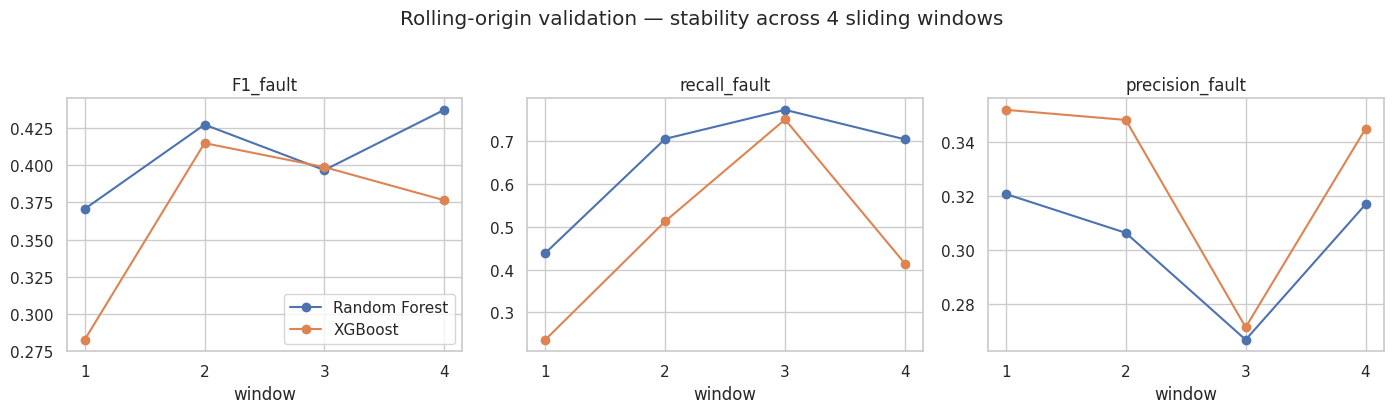

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ["F1_fault", "recall_fault", "precision_fault"]):
    for model in rolling_df["model"].unique():
        subset = rolling_df[rolling_df["model"] == model]
        ax.plot(subset["window"], subset[metric], marker="o", label=model)
    ax.set_title(metric)
    ax.set_xlabel("window")
    ax.set_xticks(rolling_df["window"].unique())
axes[0].legend()
plt.suptitle("Rolling-origin validation — stability across 4 sliding windows", y=1.03)
plt.tight_layout()
plt.show()


**Reading this honestly:** if the lines bounce around a lot window to window, the single-split
number from notebook 06 is less trustworthy as a general performance estimate — report the
mean +/- std here as the more defensible number, not the single best-looking window. If the lines
are fairly flat and consistent, that's genuine evidence notebook 06's result wasn't a lucky cutoff.
Whichever pattern actually shows above is what goes in the write-up — not assumed in advance.


## 5. Final consolidated scoreboard — every model, single-split and rolling-origin, side by side

In [7]:
with open("../models/baseline_results.json") as f:
    single_split_results = json.load(f)

single_split_df = pd.DataFrame(single_split_results).T.round(6)
single_split_df.columns = [f"single_split_{c}" for c in single_split_df.columns]

rolling_summary = rolling_df.groupby("model")[["F1_fault", "recall_fault", "precision_fault", "macro_F1_secondary"]].mean().round(6)
rolling_summary.columns = [f"rolling_origin_mean_{c}" for c in rolling_summary.columns]

print("Single-split results (notebooks 04-06):")
print(single_split_df)
print()
print("Rolling-origin mean (this notebook, Random Forest + XGBoost only):")
print(rolling_summary)


Single-split results (notebooks 04-06):
                                                    single_split_recall_fault  \
Majority class                                                       0.000000   
Naive persistence (6h lookback)                                      0.166667   
Logistic Regression (balanced, scaled, 45 featu...                   0.761380   
Random Forest (tuned, 45 features)                                   0.836270   
XGBoost (tuned, 45 features)                                         0.823789   

                                                    single_split_precision_fault  \
Majority class                                                          0.000000   
Naive persistence (6h lookback)                                         0.166667   
Logistic Regression (balanced, scaled, 45 featu...                      0.291047   
Random Forest (tuned, 45 features)                                      0.287409   
XGBoost (tuned, 45 features)                         

## 6. Limitations and honest caveats — the full list, consolidated

Every one of these was surfaced and checked during the rebuild, not glossed over. Restating them
together here so nothing gets lost between notebooks and the coach conversation.

1. **`Fault_Label` is a documented judgment call, not ground truth.** It's derived from the raw
   `DTC` column by a rule the team wrote (motor/battery codes or multiple simultaneous codes =
   Fault, single advisory code = Warning, no code = Normal) — the dataset doesn't provide a
   pre-labeled severity tier. Stated explicitly in notebook 01, Section 2.

2. **Logistic regression's coefficients ran backwards from physical intuition on 3 of 5 checked
   features.** `SOH` (positive coefficient — higher health associated with *higher* fault
   probability), `Charging_Cycles` and `Brake_Pad_Wear` (negative — more wear associated with
   *lower* fault probability) all contradict what you'd physically expect. Only `Battery_Temp`
   matched intuition cleanly. This is very likely because `Fault_Label` is derived from `DTC`
   codes, not from the sensor readings themselves — nothing in the labeling rule ties fault
   occurrence to wear-sensor values, so there's no guarantee the simulated data encodes the
   physical relationship a real vehicle would have. **This is a dataset-realism limitation, not a
   sign the model or the code is broken** — worth saying exactly that if it comes up.

3. **`Charging_Cycles` has a real, small trend-trap exposure.** 2.71% of test rows exceed the
   maximum value seen in training (checked directly on the real split in notebook 02, not assumed).
   Small, but nonzero — tree models cannot extrapolate past a feature's training range, so this is
   a genuine, quantified limitation, not a theoretical one.

4. **Random Forest leans heavily on `hour_of_day`** (importance ~0.20, roughly double the next
   feature). Justified by real evidence (a 7.3 percentage-point issue-rate spread by hour, notebook
   02) but still a large concentration of importance on one calendar feature relative to any single
   sensor reading — worth being ready to explain, not something to downplay.

5. **Random Forest and XGBoost tied on macro F1 (0.624 each) but differ sharply on recall**
   (RF 70.4% vs. XGBoost 41.4%). Since the business goal prioritizes catching faults over avoiding
   false alarms, Random Forest is the better fit *for this goal* even though the headline metric
   ties — the choice of model depends on which error costs more, not just which number is higher.

6. **Logistic regression's recall (76.1%) was the highest of any model tested**, tree models
   included. More complexity did not straightforwardly buy better recall — an honest finding, not
   the result we might have expected going in.

7. **Hyperparameter search was intentionally small** (`n_iter=4`, 2 CV folds per model, notebook 06)
   to fit this session's compute budget. Documented and reproducible, but not exhaustive — a wider
   search might change the specific numbers, though probably not the qualitative conclusions above.

8. **Single-vehicle scope.** This entire rebuild deliberately proves the method on one vehicle
   (`heavy_user`) only. It does not claim to generalize to a different vehicle or usage pattern —
   that was the explicit, stated trade for resolving the original multi-vehicle fairness critique.


## 7. What carries forward unchanged

RAG over NHTSA recall/complaint/TSB data, the LLM ticket-generation step, and the agent
orchestration (classify -> search -> generate ticket) are all untouched by this rebuild — none of
today's findings affect them.
